<a href="https://colab.research.google.com/github/hobokelamwakajumba/earthquake-explorer/blob/main/earthqauke_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Live feed: every earthquake on Earth in the last 24 hours (from the USGS)
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.csv"
quakes = pd.read_csv(url)

print("Earthquakes in the last 24 hours:", len(quakes))
quakes.head()

Earthquakes in the last 24 hours: 268


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-06-08T17:48:44.400Z,19.277666,-155.391327,30.6600,1.81,md,23,101,0.04038,0.12,...,2026-06-08T17:52:34.800Z,"12 km NE of Pāhala, Hawaii",earthquake,0.68,0.790000,0.146158,15,automatic,hv,hv
1,2026-06-08T17:37:27.220Z,62.219000,-148.174000,4.9000,3.70,ml,61,39,0.40000,1.00,...,2026-06-08T17:52:38.983Z,"49 km NNE of Chickaloon, Alaska",earthquake,2.50,2.193400,0.100000,4,automatic,ak,ak
2,2026-06-08T17:25:48.250Z,38.847168,-122.846832,0.8300,0.57,md,11,130,0.01232,0.03,...,2026-06-08T17:27:24.169Z,"11 km NW of The Geysers, CA",earthquake,0.35,0.760000,0.300000,12,automatic,nc,nc
3,2026-06-08T17:24:32.620Z,19.008167,-155.368500,34.0700,1.75,md,23,224,0.22980,0.16,...,2026-06-08T17:29:32.740Z,"23 km ESE of Naalehu, Hawaii",earthquake,1.12,1.210000,0.142307,16,automatic,hv,hv
4,2026-06-08T17:21:15.359Z,31.974000,-102.314000,3.9106,2.50,ml,91,39,0.00000,0.40,...,2026-06-08T17:37:13.040Z,"8 km SE of Gardendale, Texas",earthquake,0.00,0.569799,0.200000,65,automatic,tx,tx


In [ ]:
quakes.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-06-08T17:48:44.400Z,19.277666,-155.391327,30.6600,1.81,md,23,101,0.04038,0.12,...,2026-06-08T17:52:34.800Z,"12 km NE of Pāhala, Hawaii",earthquake,0.68,0.790000,0.146158,15,automatic,hv,hv
1,2026-06-08T17:37:27.220Z,62.219000,-148.174000,4.9000,3.70,ml,61,39,0.40000,1.00,...,2026-06-08T17:52:38.983Z,"49 km NNE of Chickaloon, Alaska",earthquake,2.50,2.193400,0.100000,4,automatic,ak,ak
2,2026-06-08T17:25:48.250Z,38.847168,-122.846832,0.8300,0.57,md,11,130,0.01232,0.03,...,2026-06-08T17:27:24.169Z,"11 km NW of The Geysers, CA",earthquake,0.35,0.760000,0.300000,12,automatic,nc,nc
3,2026-06-08T17:24:32.620Z,19.008167,-155.368500,34.0700,1.75,md,23,224,0.22980,0.16,...,2026-06-08T17:29:32.740Z,"23 km ESE of Naalehu, Hawaii",earthquake,1.12,1.210000,0.142307,16,automatic,hv,hv
4,2026-06-08T17:21:15.359Z,31.974000,-102.314000,3.9106,2.50,ml,91,39,0.00000,0.40,...,2026-06-08T17:37:13.040Z,"8 km SE of Gardendale, Texas",earthquake,0.00,0.569799,0.200000,65,automatic,tx,tx


In [ ]:
import folium

# Keep only quakes that have a location and a strength (toss the blanks)
quakes = quakes.dropna(subset=["latitude", "longitude", "mag"])

# Make a blank world map
quake_map = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Drop a dot for each earthquake
for index, row in quakes.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(row["mag"], 0.5) * 2,
        color="orangered",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['place']} (M{row['mag']})",
    ).add_to(quake_map)

# Show it
quake_map

In [ ]:
quakes.sort_values("mag", ascending=False).head(10)[["place", "mag", "depth", "time"]]

,place,mag,depth,time
219,"26 km SW of Kablalan, Philippines",7.8,55.193,2026-06-07T23:37:41.803Z
207,"19 km SW of Balangonan, Philippines",6.5,65.570,2026-06-08T00:55:12.073Z
218,"16 km WSW of Balangonan, Philippines",6.0,81.843,2026-06-07T23:48:11.405Z
217,"4 km ENE of Pangyan, Philippines",6.0,35.000,2026-06-07T23:49:13.914Z
266,Easter Island region,5.8,10.000,2026-06-07T18:01:20.966Z
206,"11 km SE of Sarangani, Philippines",5.8,52.541,2026-06-08T00:58:17.138Z
158,"54 km SSW of Sarangani, Philippines",5.7,35.000,2026-06-08T04:46:42.739Z
94,"56 km SSW of Sarangani, Philippines",5.6,35.000,2026-06-08T09:17:22.900Z
73,"12 km WSW of Balangonan, Philippines",5.5,81.095,2026-06-08T11:22:32.657Z
32,southern Mid-Atlantic Ridge,5.5,10.000,2026-06-08T14:20:10.924Z


<Axes: xlabel='depth', ylabel='mag'>

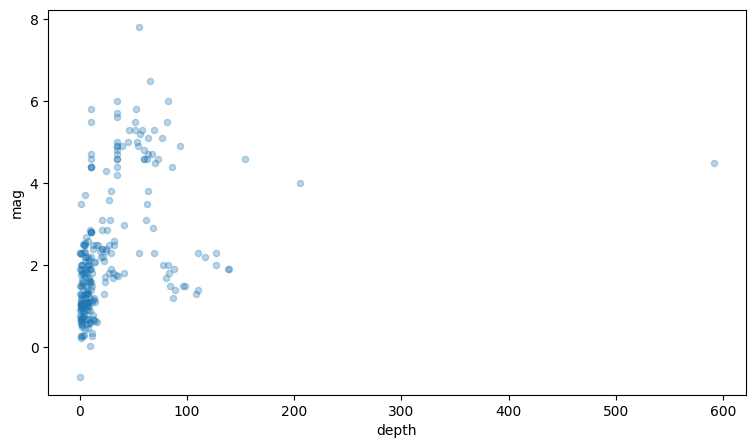

In [ ]:
quakes.plot.scatter(x="depth", y="mag", alpha=0.3, figsize=(9, 5))

In [ ]:
quakes["depth"].corr(quakes["mag"])

np.float64(0.37176214726036216)

In [ ]:
quakes["place"].str.split(", ").str[-1].value_counts().head(10)

,count
place,
CA,87
Alaska,67
Philippines,37
Texas,19
Hawaii,11
Nevada,8
New Mexico,7
Puerto Rico,4
Oklahoma,4


In [ ]:
from sklearn.cluster import KMeans

# Drop any quake missing a location, so the model doesn't trip
quakes = quakes.dropna(subset=["latitude", "longitude"])

# The two things the model will look at: where each quake is
coords = quakes[["latitude", "longitude"]]

# Build the model and tell it to find 5 zones
model = KMeans(n_clusters=5, random_state=42, n_init=10)

# Train it — sorts every quake into a zone (0–4) and saves the labels
quakes["cluster"] = model.fit_predict(coords)

# Proof it worked: how many quakes landed in each zone
quakes["cluster"].value_counts()

,count
cluster,
2,135
3,65
1,44
0,12
4,12


<Axes: xlabel='longitude', ylabel='latitude'>

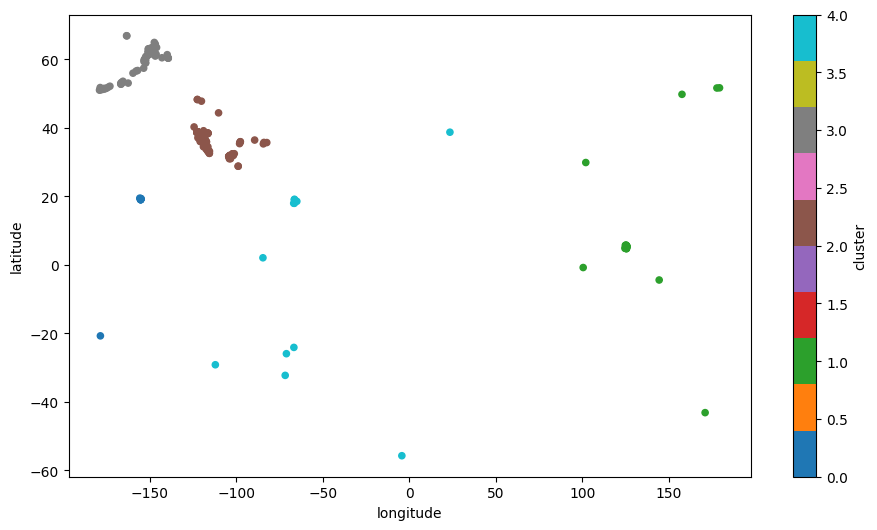

In [ ]:
quakes.plot.scatter(x="longitude", y="latitude", c="cluster", colormap="tab10", figsize=(11, 6))